In [44]:
pip install --upgrade datasets

In [45]:
token = "hf_REDACTED"
from huggingface_hub import login
login(token)

In [46]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_id = "google/gemma-3-270m-it"
tokenizer = AutoTokenizer.from_pretrained(model_id, token=token)
model = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto", torch_dtype=torch.float16)



```
# This is formatted as code
```

<h1><b>Sentiment Analysis</b></h1>

---
Dataset : IMDB ,
Totall Samples : 1000

In [47]:
def batch_zero_shot_prompt(review):
    return f"""You are a sentiment analysis expert.

Review: "{review[0]}"

What is the sentiment of movie review above.Choose only one of the following:
- Positive
- Negative

Respond with one word only:

Answer:"""

In [48]:
import re
def extract_sentiment(response):
    """Extracts 'Positive' or 'Negative' from the response using regex"""
    matches = re.findall(r'(Positive|Negative)', response, re.IGNORECASE)
    return matches[-1].capitalize() if matches else "Unknown"

In [49]:
from datasets import load_dataset

# Load the IMDb test subset
dataset = load_dataset("imdb", split="test")
shuffled_dataset = dataset.shuffle(seed=42)

Samples = shuffled_dataset.select(range(1000))

# IMDb labels: 0 = negative, 1 = positive
label_counts = {"positive": 0, "negative": 0}

# Count positive and negative labels
for example in Samples:
    label = example["label"]
    if label == 1:
        label_counts["positive"] += 1
    else:
        label_counts["negative"] += 1

print("Total reviews:", len(dataset))
print("Positive reviews:", label_counts["positive"])
print("Negative reviews:", label_counts["negative"])


Total reviews: 25000
Positive reviews: 488
Negative reviews: 512


In [50]:
texts = []
true_labels = []
for i in range (0,len(Samples['text'])):
    texts.append(Samples['text'][i])
for i in range (0,len(Samples['text'])):
    true_labels.append(Samples['label'][i])
print(Samples)
print(len(texts))
print(len(true_labels))

Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})
1000
1000


In [51]:
pip install codecarbon

In [52]:
from codecarbon import EmissionsTracker

tracker = EmissionsTracker(
    project_name="gemma-3-270m-it",
    output_dir=".",          # where the CSV will be saved
    tracking_mode="process", # tracks CPU/GPU for this process only
    measure_power_secs=5,
    log_level="error"
)


In [53]:
batch_size = 1
predicted_labels = []

max_len = min(2048, getattr(model.config, "max_position_embeddings", 2048))

tracker.start()

for i in range(0, len(Samples), batch_size):
    text = Samples[i]["text"]   # get a single string, not a list

    prompt = batch_zero_shot_prompt(text)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_len,
        padding=False
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False,   # <- avoids multinomial sampling crash
            num_beams=1
        )

    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    prediction = extract_sentiment(decoded)
    predicted_labels.append(prediction)

emissions = tracker.stop()


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for o

In [54]:
max_len = min(2048, getattr(model.config, "max_position_embeddings", 2048))

inputs = tokenizer(
    prompt,
    return_tensors="pt",
    truncation=True,
    max_length=max_len
).to(model.device)

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=False,
        num_beams=1
    )

decoded = tokenizer.decode(output[0], skip_special_tokens=True)
print(decoded)


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


You are a sentiment analysis expert.

Review: "T"

What is the sentiment of movie review above.Choose only one of the following:
- Positive
- Negative

Respond with one word only:

Answer:


In [55]:
# Map predictions to 0/1
predictions = [1 if s == "Positive" else 0 for s in predicted_labels]

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)



Accuracy: 0.512
F1 Score: 0.0
Recall: 0.0
Precision: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [56]:
import pandas as pd

df = pd.read_csv("emissions.csv")
latest = df.iloc[-1]


NUM_SAMPLES= 1000
print("\n========== CodeCarbon Summary ==========\n")

print(f"Project name           : {latest['project_name']}")
print(f"Duration (s)           : {latest['duration']:.2f}")

print("\n--- Energy ---")
print(f"Total energy (kWh)     : {latest['energy_consumed']:.6f}")
print(f"Energy per sample (J)  : {(latest['energy_consumed']/NUM_SAMPLES)*3.6e6:.2f}")
print(f"Energy per 1k samples (kJ): {(latest['energy_consumed']/NUM_SAMPLES)*3.6e3:.2f}")

print("\n--- Carbon ---")
print(f"CO₂ emissions (kg)     : {latest['emissions']:.6f}")
print(f"CO₂ per sample (g)     : {(latest['emissions']/NUM_SAMPLES)*1000:.4f}")

print("\n--- Time ---")
print(f"Avg time per sample (s): {latest['duration']/NUM_SAMPLES:.3f}")

print("\n--- Hardware ---")
print(f"CPU                    : {latest['cpu_model']}")
print(f"GPU                    : {latest['gpu_model']}")
print(f"RAM (GB)               : {latest['ram_total_size']}")

print("\n--- Environment ---")
print(f"Platform               : Google Colab")
print(f"Country (est.)         : {latest['country_name']}")
print(f"Cloud provider         : {latest['cloud_provider']}")
print(f"Tracking mode          : {latest['tracking_mode']}")

print("\n=======================================\n")



========== CodeCarbon Summary ==========

Project name           : gemma-3-270m-it
Duration (s)           : 238.73

--- Energy ---
Total energy (kWh)     : 0.005860
Energy per sample (J)  : 21.10
Energy per 1k samples (kJ): 0.02

--- Carbon ---
CO₂ emissions (kg)     : 0.000813
CO₂ per sample (g)     : 0.0008

--- Time ---
Avg time per sample (s): 0.239

--- Hardware ---
CPU                    : Intel(R) Xeon(R) CPU @ 2.20GHz
GPU                    : 1 x Tesla T4
RAM (GB)               : 12.671436309814451

--- Environment ---
Platform               : Google Colab
Country (est.)         : United States
Cloud provider         : nan
Tracking mode          : process




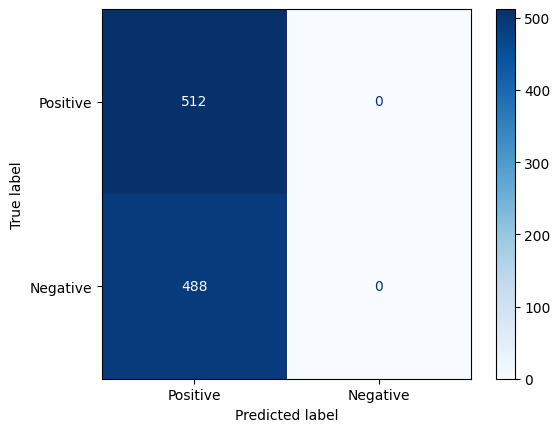

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Positive", "Negative"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

<h1><b>Hate Speech Detection</b></h1>

---
Dataset : OLID ,
Totall Samples : 400



In [58]:
from datasets import load_dataset

dataset = load_dataset("christophsonntag/OLID", split="test")
dataset[5]


{'id': 83681,
 'tweet': '. . . What the fuck did he do this time?',
 'cleaned_tweet': 'fuck time',
 'subtask_a': 'OFF',
 'subtask_b': 'TIN',
 'subtask_c': 'IND'}

In [59]:
dataset

Dataset({
    features: ['id', 'tweet', 'cleaned_tweet', 'subtask_a', 'subtask_b', 'subtask_c'],
    num_rows: 860
})

In [60]:
shuffled_dataset = dataset.shuffle(seed=42).select(range(800))

shuffled_dataset

Dataset({
    features: ['id', 'tweet', 'cleaned_tweet', 'subtask_a', 'subtask_b', 'subtask_c'],
    num_rows: 800
})

In [61]:
negatives = shuffled_dataset.filter(lambda x: x['subtask_a'] == 'OFF').select(range(200))
positives = shuffled_dataset.filter(lambda x: x['subtask_a'] == 'NOT').select(range(200))

# Combine both subsets
from datasets import concatenate_datasets
Samples = concatenate_datasets([negatives, positives])

In [62]:
Samples = Samples.shuffle()

In [63]:
label_counts = {"OFF": 0, "NOT": 0}

# Count positive and negative labels
for example in Samples:
    label = example["subtask_a"]
    if label == 'OFF':
        label_counts["OFF"] += 1
    else:
        label_counts["NOT"] += 1

print("Total tweets:", len(Samples))
print("Offensive tweets:", label_counts["OFF"])
print("Non-offensive tweets:", label_counts["NOT"])

Total tweets: 400
Offensive tweets: 200
Non-offensive tweets: 200


In [64]:
tweets = []
true_labels = []
for i in range (0,len(Samples['tweet'])):
    tweets.append(Samples['cleaned_tweet'][i])
for i in range (0,len(Samples['tweet'])):
    true_labels.append(Samples['subtask_a'][i])
print(Samples)
print(len(tweets))
print(len(true_labels))

Dataset({
    features: ['id', 'tweet', 'cleaned_tweet', 'subtask_a', 'subtask_b', 'subtask_c'],
    num_rows: 400
})
400
400


In [65]:
tweets[0]

'antifa ts level influence scary'

In [66]:
def batch_zero_shot_prompt(review):
    return f"""Read this tweet below :

Tweet: "{review[0]}"

Now tell me if the tweet is :
- Offensive
- Non-offensive

Answer in one word only.

Answer:
"""


In [67]:
import re
def extract_detection(response):
    """Extracts 'Positive' or 'Negative' from the response using regex"""
    matches = re.findall(r'(Offensive|Non-offensive)', response, re.IGNORECASE)
    return matches[-1].capitalize() if matches else "Unknown"

In [68]:
batch_size = 1
predicted_labels = []

for i in range(0, len(Samples), batch_size):
    text = Samples[i]["tweet"]   # ✅ FIXED

    prompt = batch_zero_shot_prompt(text)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    output = model.generate(
        **inputs,
        max_new_tokens=5,
        do_sample=False,
        eos_token_id=tokenizer.eos_token_id,
        early_stopping=True
    )

    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    prediction = extract_detection(decoded)
    predicted_labels.append(prediction)


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for o

In [69]:
# Map predictions to 0/1
predictions = [1 if s == "Offensive" else 0 for s in predicted_labels]
actual = [1 if s == 'OFF' else 0 for s in true_labels]

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(actual, predictions)
f1 = f1_score(actual, predictions)
recall = recall_score(actual, predictions)
precision = precision_score(actual, predictions)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)


Accuracy: 0.5
F1 Score: 0.0
Recall: 0.0
Precision: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


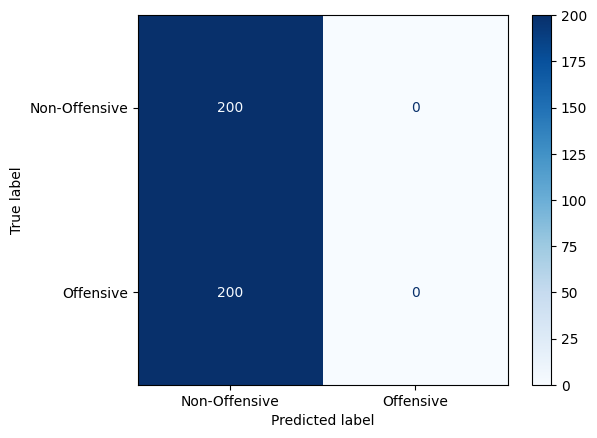

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(actual, predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Offensive", "Offensive"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [71]:
import pandas as pd

df = pd.read_csv("emissions.csv")
latest = df.iloc[-1]


NUM_SAMPLES= 400
print("\n========== CodeCarbon Summary ==========\n")

print(f"Project name           : {latest['project_name']}")
print(f"Duration (s)           : {latest['duration']:.2f}")

print("\n--- Energy ---")
print(f"Total energy (kWh)     : {latest['energy_consumed']:.6f}")
print(f"Energy per sample (J)  : {(latest['energy_consumed']/NUM_SAMPLES)*3.6e6:.2f}")
print(f"Energy per 1k samples (kJ): {(latest['energy_consumed']/NUM_SAMPLES)*3.6e3:.2f}")

print("\n--- Carbon ---")
print(f"CO₂ emissions (kg)     : {latest['emissions']:.6f}")
print(f"CO₂ per sample (g)     : {(latest['emissions']/NUM_SAMPLES)*1000:.4f}")

print("\n--- Time ---")
print(f"Avg time per sample (s): {latest['duration']/NUM_SAMPLES:.3f}")

print("\n--- Hardware ---")
print(f"CPU                    : {latest['cpu_model']}")
print(f"GPU                    : {latest['gpu_model']}")
print(f"RAM (GB)               : {latest['ram_total_size']}")

print("\n--- Environment ---")
print(f"Platform               : Google Colab")
print(f"Country (est.)         : {latest['country_name']}")
print(f"Cloud provider         : {latest['cloud_provider']}")
print(f"Tracking mode          : {latest['tracking_mode']}")

print("\n=======================================\n")



========== CodeCarbon Summary ==========

Project name           : gemma-3-270m-it
Duration (s)           : 238.73

--- Energy ---
Total energy (kWh)     : 0.005860
Energy per sample (J)  : 52.74
Energy per 1k samples (kJ): 0.05

--- Carbon ---
CO₂ emissions (kg)     : 0.000813
CO₂ per sample (g)     : 0.0020

--- Time ---
Avg time per sample (s): 0.597

--- Hardware ---
CPU                    : Intel(R) Xeon(R) CPU @ 2.20GHz
GPU                    : 1 x Tesla T4
RAM (GB)               : 12.671436309814451

--- Environment ---
Platform               : Google Colab
Country (est.)         : United States
Cloud provider         : nan
Tracking mode          : process




<h1><b>News Classification</b></h1>

---



In [72]:
from datasets import load_dataset
print("=== AG News ===")
ag_news = load_dataset("ag_news", split="test")
ag_news

=== AG News ===


Dataset({
    features: ['text', 'label'],
    num_rows: 7600
})

In [73]:
ag_news.features['label']

ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])

In [74]:
ag_news[4]

{'text': "Calif. Aims to Limit Farm-Related Smog (AP) AP - Southern California's smog-fighting agency went after emissions of the bovine variety Friday, adopting the nation's first rules to reduce air pollution from dairy cow manure.",
 'label': 3}

In [75]:
World = ag_news.filter(lambda x: x['label'] == 0).select(range(150))
Sports = ag_news.filter(lambda x: x['label'] == 1).select(range(150))
Business = ag_news.filter(lambda x: x['label'] == 2).select(range(150))
SciTech = ag_news.filter(lambda x: x['label'] == 3).select(range(150))

from datasets import concatenate_datasets
Samples = concatenate_datasets([World, Sports,Business,  SciTech])

In [76]:
Samples[42]

{'text': 'Israelis OK new homes in West Bank A leaked Israeli plan to build 1,000 new Jewish settler homes in the West Bank yesterday sent Bush administration officials scrambling for a response in the sensitive period before November #39;s presidential election. ',
 'label': 0}

In [77]:
Samples = Samples.shuffle()

In [78]:
label_counts = {"World":0, "Sports": 0, "Business" :0, "Sci/Tech": 0}

# Count labels
for example in Samples:
    label = example["label"]
    if label == 0:
        label_counts["World"] += 1
    elif label == 1:
        label_counts["Sports"] += 1
    elif label == 2:
        label_counts["Business"] += 1
    else:
        label_counts["Sci/Tech"] += 1

print("Total :", len(Samples))
print("World:", label_counts["World"])
print("Sports:", label_counts["Sports"])
print("Business:", label_counts["Business"])
print("Sci/Tech", label_counts["Sci/Tech"])

Total : 600
World: 150
Sports: 150
Business: 150
Sci/Tech 150


In [79]:
news = []
true_labels = []
for example in Samples:
    emotion = example["text"]
    label = example["label"]
    news.append(emotion)
    true_labels.append(label)

print(Samples)
print(len(news))
print(len(true_labels))

Dataset({
    features: ['text', 'label'],
    num_rows: 600
})
600
600


In [80]:
print(Samples[300])
print(news[300])
print(true_labels[300])

{'text': 'Work done, Phelps basks in gold glor And on the eighth day, Michael Phelps actually got to rest. After swimming some 18 races in Olympic competition, Phelps was a mere spectator last night, watching his teammates cap a terrific week for the US swim team.', 'label': 1}
Work done, Phelps basks in gold glor And on the eighth day, Michael Phelps actually got to rest. After swimming some 18 races in Olympic competition, Phelps was a mere spectator last night, watching his teammates cap a terrific week for the US swim team.
1


In [81]:
def news_classification_prompt(article):
    return f"""You are an AI assistant trained to classify news articles based on their content.

Article: "{article[0]}"

Classify the article into one of the following categories:
- World
- Sports
- Business
- SciTech

Answer in one word only.

Answer:"""

In [82]:
import re
def extract_sentiment(response):
    """Extracts 'Positive' or 'Negative' from the response using regex"""
    matches = re.findall(r'(World|Sports|Business|SciTech)', response, re.IGNORECASE)
    return matches[-1].capitalize() if matches else "Unknown"

In [83]:
batch_size = 1
predicted_labels = []

model.eval()

for i in range(0, len(Samples), batch_size):
    text = Samples[i]["text"]
    prompt = news_classification_prompt(text)

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(model.device)

    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    prediction = extract_sentiment(decoded)
    predicted_labels.append(prediction)

    if i % 10 == 0:   # ✅ print every 10 samples
        print(f"done {i+1}/{len(Samples)} → {prediction}")



done 1/600 → Scitech
done 11/600 → Scitech
done 21/600 → Scitech
done 31/600 → Scitech
done 41/600 → Scitech
done 51/600 → Scitech
done 61/600 → Scitech
done 71/600 → Scitech
done 81/600 → Scitech
done 91/600 → Scitech
done 101/600 → Scitech
done 111/600 → Scitech
done 121/600 → Scitech
done 131/600 → Scitech
done 141/600 → Scitech
done 151/600 → Scitech
done 161/600 → Scitech
done 171/600 → Scitech
done 181/600 → Scitech
done 191/600 → Scitech
done 201/600 → Scitech
done 211/600 → Scitech
done 221/600 → Scitech
done 231/600 → Scitech
done 241/600 → Scitech
done 251/600 → Scitech
done 261/600 → Scitech
done 271/600 → Scitech
done 281/600 → Scitech
done 291/600 → Scitech
done 301/600 → Scitech
done 311/600 → Scitech
done 321/600 → Scitech
done 331/600 → Scitech
done 341/600 → Scitech
done 351/600 → Scitech
done 361/600 → Scitech
done 371/600 → Scitech
done 381/600 → Scitech
done 391/600 → Scitech
done 401/600 → Scitech
done 411/600 → Scitech
done 421/600 → Scitech
done 431/600 → Scitech

In [84]:
# Map predictions to 0/1
label_map = {
    "World": 0,
    "Sports": 1,
    "Business": 2,
    "Scitech": 3
}

predictions = [label_map[s] for s in predicted_labels]

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions, average='macro')
recall = recall_score(true_labels, predictions, average='macro')
precision = precision_score(true_labels, predictions, average='macro')

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)


Accuracy: 0.25
F1 Score: 0.1
Recall: 0.25
Precision: 0.0625


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


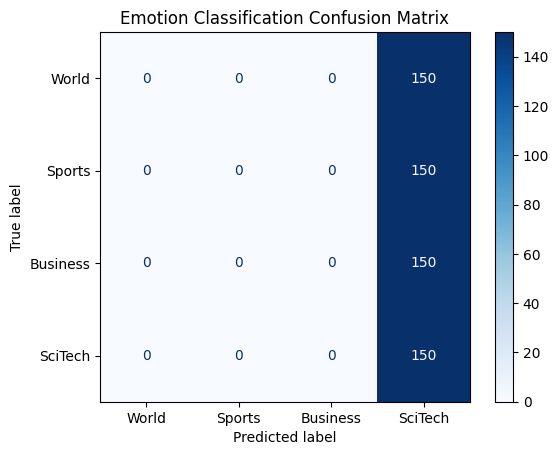

In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["World","Sports", "Business","SciTech"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Emotion Classification Confusion Matrix")
plt.show()

In [86]:
import pandas as pd

df = pd.read_csv("emissions.csv")
latest = df.iloc[-1]


NUM_SAMPLES= 1000
print("\n========== CodeCarbon Summary ==========\n")

print(f"Project name           : {latest['project_name']}")
print(f"Duration (s)           : {latest['duration']:.2f}")

print("\n--- Energy ---")
print(f"Total energy (kWh)     : {latest['energy_consumed']:.6f}")
print(f"Energy per sample (J)  : {(latest['energy_consumed']/NUM_SAMPLES)*3.6e6:.2f}")
print(f"Energy per 1k samples (kJ): {(latest['energy_consumed']/NUM_SAMPLES)*3.6e3:.2f}")

print("\n--- Carbon ---")
print(f"CO₂ emissions (kg)     : {latest['emissions']:.6f}")
print(f"CO₂ per sample (g)     : {(latest['emissions']/NUM_SAMPLES)*1000:.4f}")

print("\n--- Time ---")
print(f"Avg time per sample (s): {latest['duration']/NUM_SAMPLES:.3f}")

print("\n--- Hardware ---")
print(f"CPU                    : {latest['cpu_model']}")
print(f"GPU                    : {latest['gpu_model']}")
print(f"RAM (GB)               : {latest['ram_total_size']}")

print("\n--- Environment ---")
print(f"Platform               : Google Colab")
print(f"Country (est.)         : {latest['country_name']}")
print(f"Cloud provider         : {latest['cloud_provider']}")
print(f"Tracking mode          : {latest['tracking_mode']}")

print("\n=======================================\n")



========== CodeCarbon Summary ==========

Project name           : gemma-3-270m-it
Duration (s)           : 238.73

--- Energy ---
Total energy (kWh)     : 0.005860
Energy per sample (J)  : 21.10
Energy per 1k samples (kJ): 0.02

--- Carbon ---
CO₂ emissions (kg)     : 0.000813
CO₂ per sample (g)     : 0.0008

--- Time ---
Avg time per sample (s): 0.239

--- Hardware ---
CPU                    : Intel(R) Xeon(R) CPU @ 2.20GHz
GPU                    : 1 x Tesla T4
RAM (GB)               : 12.671436309814451

--- Environment ---
Platform               : Google Colab
Country (est.)         : United States
Cloud provider         : nan
Tracking mode          : process


